# Logistic Regression


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
! kaggle datasets download brendan45774/mlr
!unzip mlr.zip


Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
Archive:  mlr.zip
replace multiple_linear_regression_dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: multiple_linear_regression_dataset.csv  


In [ ]:
df = pd.read_csv('/content/multiple_linear_regression_dataset.csv')
df

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830
5,51,7,41630
6,28,5,41340
7,33,4,37650
8,37,5,40250
9,39,8,45150


In [ ]:
# Define features and target
X = df[['age', 'experience']]
y = df['income']

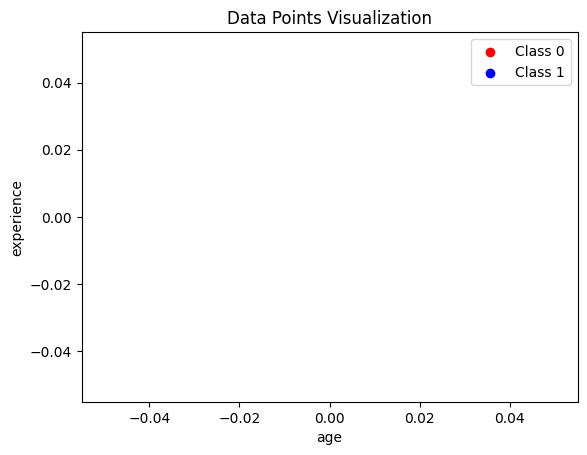

In [ ]:
plt.scatter(df[df['income'] == 0]['age'], df[df['income'] == 0]['experience'], color='red', label='Class 0')
plt.scatter(df[df['income'] == 1]['age'], df[df['income'] == 1]['experience'], color='blue', label='Class 1')

plt.xlabel('age')
plt.ylabel('experience')
plt.title('Data Points Visualization')
plt.legend()
plt.show()

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train)
print(y_train)
print("............................................")
print(X_test)
print(y_test)


    age  experience
8    37           5
5    51           7
11   47           9
3    32           5
18   44           9
16   58          17
13   51           4
2    47           2
9    39           8
19   37          10
4    43          10
12   54           5
7    33           4
10   29           1
14   44          12
6    28           5
8     40250
5     41630
11    46110
3     40130
18    44190
16    63600
13    34800
2     31580
9     45150
19    48700
4     47830
12    36720
7     37650
10    27840
14    51300
6     41340
Name: income, dtype: int64
............................................
    age  experience
0    25           1
17   23           1
15   41           6
1    30           3
0     30450
17    30870
15    38900
1     35670
Name: income, dtype: int64


In [ ]:
# Create and train the logistic regression model
model = LogisticRegression(max_iter=100000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=100000)

In [ ]:
# Make predictions
y_pred = model.predict(X_test)
print(y_pred)
print(y_test)

[27840 27840 40250 27840]
0     30450
17    30870
15    38900
1     35670
Name: income, dtype: int64


[-0.74917604 -0.93335096] 33.63270823421421


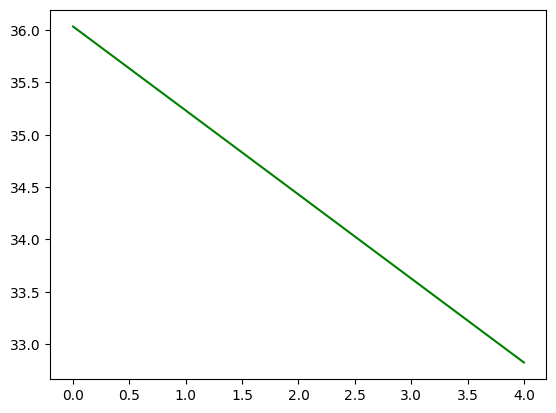

In [ ]:
# **Plotting Decision Boundary**
plt.scatter(df[df['income'] == 0]['age'], df[df['income'] == 0]['experience'], color='red', label='Class 0')
plt.scatter(df[df['income'] == 1]['age'], df[df['income'] == 1]['experience'], color='blue', label='Class 1')

coef = model.coef_[0]
intercept = model.intercept_[0]
print(coef,intercept)
# Create a range of values for Feature1
x_values = np.linspace(0, 4, 100)
# Calculate corresponding values for Feature2 using the decision boundary equation
y_values = -(coef[0] * x_values + intercept) / coef[1]

plt.plot(x_values, y_values, label='Decision Boundary', color='green')

plt.show()

In [ ]:
df.head()

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [ ]:
print(df.shape)

(20, 3)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         20 non-null     int64
 1   experience  20 non-null     int64
 2   income      20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes
None


In [ ]:
print(df.nunique())

age           16
experience    12
income        20
dtype: int64


In [ ]:
# dropping the income column
df_new = df.drop('income',axis=1)
df_new.head()

,age,experience
0,25,1
1,30,3
2,47,2
3,32,5
4,43,10


In [ ]:
encoded_df = pd.get_dummies(df_new, columns=['age'], drop_first=True)
encoded_df.head()

,experience,age_25,age_28,age_29,age_30,age_32,age_33,age_37,age_39,age_41,age_43,age_44,age_47,age_51,age_54,age_58
0,1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
2,2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,5,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,10,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False


In [ ]:
# getting the independent and dependent variable
X = encoded_df.drop('experience',axis=1)
Y = encoded_df[['experience']]

In [ ]:
Y

,experience
0,1
1,3
2,2
3,5
4,10
5,7
6,5
7,4
8,5
9,8


In [ ]:
# Splitting the data into train and test set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [ ]:
# creating the object of  LinearRegression
lr = LogisticRegression()
# fitting the model(training the model)
lr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [ ]:
# Evaluating the model
print(lr.score(x_test, y_test))

0.0


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
pred=lr.predict(x_test)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
cm=confusion_matrix(y_test,pred)

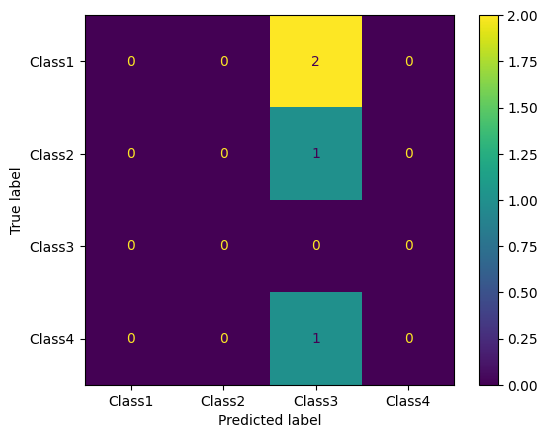

In [ ]:
dis=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Class1','Class2','Class3','Class4'])
dis.plot()
plt.show()